In [ ]:
import sys, os
# Fix paths so kit.py and data/ are always found from project root
ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

In [26]:
import numpy as np 
import pandas as pd
import kit as erk
import seaborn as sns


In [27]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
def bt_mix(r1, r2, allocator, **kwargs):
    """ 
    Run a back test by allocating a two sets of return r1 and r2 are TxN dataframes where T is the time step index and N is the number of scenarios.
    allocator is a function that take two sets of returns and allocators specifc parameters, and produces an allocation to the first portfolio as a Tx1 dataFrame
    Return a TxN DataFrameof the resulting N Portfolio scenarios
    """

    if not r1.shape == r2.shape:
        raise ValueError("r1 and r2 need to be the same shape")
    weights = allocator(r1, r2, **kwargs)
    if not weights.shape == r1.shape:
        raise ValueError("Allocator return weights that don''t match r1")
    r_mix = weights*r1 + (1-weights)*r2
    return r_mix

In [29]:
def fixedmix_allocator(r1, r2, w1, **kwargs):
    """ 
    Produces a time series over T steps of allocation between the PSP and GHP across N scenarios
    PSP and GHP are TxN DataFrame that represent the returns of the PSP and GHP such that:
      each column is a scenario
      each row is the price of a timestep
    Return an TxN dataFrame of PSP Weights
    """  
    return pd.DataFrame(data=w1, index=r1.index, columns=r1.columns)

In [30]:
rates, zc_prices = erk.cir(10, 500, b=0.03, r_0=0.03)
price_10 = erk.bond_price(10, 100, .05, 12, rates)
price_30 = erk.bond_price(30, 100, .05, 12, rates)
rets_30 = erk.bond_total_return(price_30, 100, .05, 12)
rets_10 = erk.bond_total_return(price_10, 100, .05, 12)

/Users/phamthanh/Documents/ESSCA | MSc Finance & Data Analyst/Semester 2/9. Introduction to Portfolio Construction/kit.py:688: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  coupons.iloc[pay_date] = (principal * coupon_rate) / coupon_per_year
/Users/phamthanh/Documents/ESSCA | MSc Finance & Data Analyst/Semester 2/9. Introduction to Portfolio Construction/kit.py:688: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  coupons.iloc[pay_date] = (principal * coupon_rate) / coupon_per_year
/Users/phamthanh/Documents/ESSCA | MSc Finance & Data Analyst/Semester 2/9. Introduction to Portfolio Construction/kit.py:688: Futur

In [31]:
rets_bonds = erk.bt_mix(rets_10, rets_30, allocator=erk.fixedmix_allocator, w1=.6)
mean_rets_bond =  rets_bonds.mean(axis="columns")
erk.summary_stats(pd.DataFrame(mean_rets_bond))

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Kurtosis,Skew,Sharp Ratio,CVaR 5% (Gaussian),Historic CVaR 5%
0,0.03621,0.003554,1.700553,0.0,3.601939,0.255972,1.700553,-0.001377,-0.0009


In [42]:
rets_bonds

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
1,0.040141,0.017398,0.028011,0.002439,0.026413,-0.00735,-0.008097,-0.022486,0.000926,0.029069,...,-0.025158,-0.066335,0.083879,-0.000476,0.019442,-0.004085,0.002979,0.051258,0.043092,0.007835
2,-0.006714,-0.018121,0.020789,0.001333,0.012311,-0.077098,-0.038667,-0.042242,0.045107,-0.037575,...,-0.049941,-0.003905,-0.013647,0.019496,-0.030664,0.005083,0.014175,0.057933,0.016824,0.007144
3,-0.01907,0.02205,0.026341,-0.012082,0.000296,0.022983,0.004802,0.018342,0.022758,0.014347,...,0.029535,-0.004197,0.009797,-0.003454,0.016427,-0.017039,0.033117,0.013966,-0.008513,-0.018518
4,0.02363,0.061918,-0.0294,-0.035464,-0.001369,0.017654,-0.065545,0.026665,-0.003623,-0.023796,...,-0.022,-0.025817,0.032398,0.013593,-0.023495,-0.0169,-0.05004,0.022413,0.034604,-0.011096
5,0.036596,-0.022219,0.018516,-0.040375,-0.020012,0.022634,0.00425,0.001157,0.019329,0.025272,...,-0.013046,0.012851,0.002589,0.015122,-0.043551,-0.004142,0.016927,-0.021981,-0.012997,0.018341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,-0.010785,-0.004308,0.009306,0.003572,0.007882,0.001091,0.033209,0.027061,0.001889,0.019009,...,0.022277,-0.006398,0.005886,0.014921,-0.005311,0.037965,-0.00534,0.000056,-0.002293,-0.017371
117,0.004689,0.01368,0.003323,-0.002696,-0.014286,0.024668,0.02621,0.008116,0.008411,0.013156,...,0.043665,0.012999,0.006589,-0.001043,-0.026182,-0.003102,0.012462,-0.008729,0.004332,-0.008493
118,-0.010953,-0.002411,0.004256,0.000789,0.005255,0.032756,0.026938,-0.006129,0.007963,0.002547,...,-0.00563,-0.00449,-0.000327,-0.013922,0.007983,-0.030502,0.004584,0.012097,-0.003678,0.014932
119,0.001289,-0.003317,0.015775,0.000035,0.007085,-0.016663,-0.029945,0.001085,-0.014282,0.006872,...,0.015071,0.014394,0.008196,0.015364,-0.018669,0.025624,-0.028056,-0.003462,-0.001624,0.000235


In [32]:
price_eq= erk.gbm(n_years=10, n_scenarios=500, mu=0.07, sigma=0.15)
rets_eq = price_eq.pct_change().dropna()
rets_zc = zc_prices.pct_change().dropna()

In [33]:
rets_7030b = erk.bt_mix(rets_eq, rets_bonds, allocator = erk.fixedmix_allocator, w1=0.7)
rets_7030b_mean = rets_7030b.mean(axis=1)
erk.summary_stats(pd.DataFrame(rets_7030b_mean))

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Kurtosis,Skew,Sharp Ratio,CVaR 5% (Gaussian),Historic CVaR 5%
0,0.058733,0.004488,6.231693,0.0,2.988818,-0.282347,6.231693,-0.002544,-0.001838


In [34]:
summaries = erk.summary_stats(rets_7030b)

In [35]:
summaries.head()

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Kurtosis,Skew,Sharp Ratio,CVaR 5% (Gaussian),Historic CVaR 5%
0,0.031933,0.101574,0.018399,-0.309313,3.672769,-0.203613,0.018399,0.046249,0.056894
1,0.088471,0.101945,0.558129,-0.152815,2.903677,0.037054,0.558129,0.040436,0.051281
2,0.032977,0.124080,0.023197,-0.256468,2.489402,0.143990,0.023197,0.054224,0.063475
3,0.084485,0.116792,0.453920,-0.224753,2.363849,-0.199142,0.453920,0.050187,0.060928
4,0.045237,0.109286,0.135559,-0.139301,3.038200,-0.133160,0.135559,0.048643,0.064610


In [36]:
summaries.mean()

Annualized Return        0.053298
Annualized Volatility    0.107516
Sharpe Ratio             0.211697
Max Drawdown            -0.212458
Kurtosis                 2.978156
Skew                    -0.009661
Sharp Ratio              0.211697
CVaR 5% (Gaussian)       0.046142
Historic CVaR 5%         0.058478
dtype: float64

In [37]:
def terminal_value(rets):
    """ 
    Return the final value of a dollor at the end of return period
    """
    return (rets+1).prod()

In [38]:
pd.concat([
    erk.terminal_stats(rets_bonds, name="FI"),
    erk.terminal_stats(rets_eq, name="Eq"),
    erk.terminal_stats(rets_7030b, name="70/30")
], axis=1)

,FI,Eq,70/30
mean,1.387834,1.962643,1.775749
stdev,0.110535,1.052050,0.646574
min,1.031344,0.411597,0.616363
max,1.615108,8.252700,4.790976
p_breach,0.000000,0.058000,0.014000
e_short,0.000000,0.136629,0.066662
e_surplus,0.000000,0.000000,0.000000


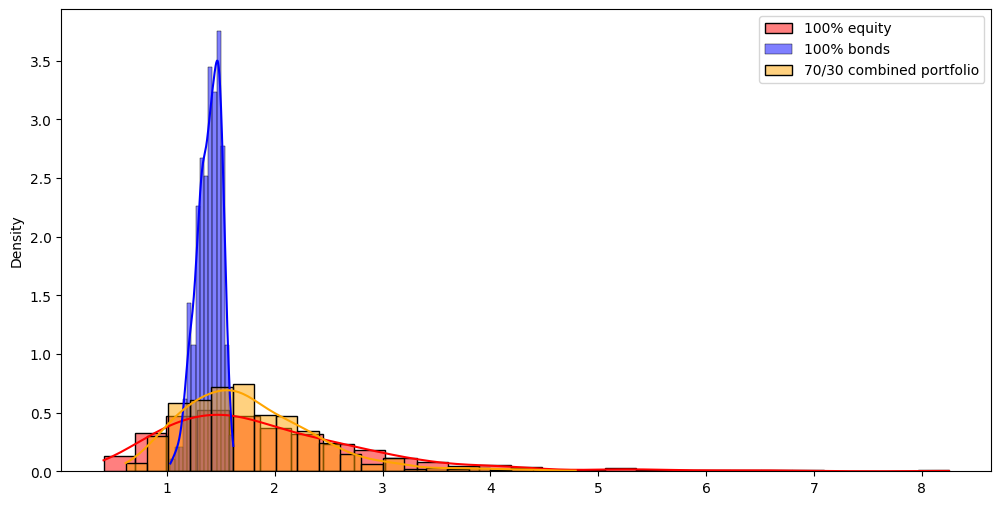

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.histplot(erk.terminal_values(rets_eq), color="red", label="100% equity", kde=True, stat="density")
sns.histplot(erk.terminal_values(rets_bonds), color="blue", label="100% bonds", kde=True, stat="density")
sns.histplot(erk.terminal_values(rets_7030b), color="orange", label="70/30 combined portfolio", kde=True, stat="density")

plt.legend()
plt.show()

# Glide Paths for Allocation

In [40]:
def glide_path_allocator(r1, r2, start_glide=1, end_glide=0): 
    """ 
    Simulate a target date-fund style gradual move from r1 to r2
    """ 
    n_points  = r1.shape[0]
    n_cols = r1.shape[1]
    path = pd.Series(data=np.linspace(start_glide, end_glide, num=n_points))
    paths = pd.concat([path]*n_cols, axis=1)
    paths.index = r1.index
    paths.columns = r1.columns

    return paths

In [41]:
rets_g8020 = erk.bt_mix(rets_eq, rets_bonds, allocator=erk.glide_path_allocator, start_glide=.80, end_glide=.20)
pd.concat([
    erk.terminal_stats(rets_bonds, name="FI"),
    erk.terminal_stats(rets_eq, name="Eq"),
    erk.terminal_stats(rets_7030b, name="70/30"),
    erk.terminal_stats(rets_g8020, name="Glide 80 to 20")
], axis=1)

,FI,Eq,70/30,Glide 80 to 20
mean,1.387834,1.962643,1.775749,1.663976
stdev,0.110535,1.052050,0.646574,0.463484
min,1.031344,0.411597,0.616363,0.755429
max,1.615108,8.252700,4.790976,3.559936
p_breach,0.000000,0.058000,0.014000,0.004000
e_short,0.000000,0.136629,0.066662,0.033774
e_surplus,0.000000,0.000000,0.000000,0.000000
